# Support Vector Machine — Scikit-Learn

**Dataset:** MAGIC Gamma Telescope (UCI) — 18,905 samples, 10 features, binary classification  
**Task:** Classify cosmic ray observations as gamma rays (signal) or hadrons (background noise)  
**Framework showcase:** Kernel Comparison — linear vs RBF vs polynomial

## Structure
- Train SVC with RBF kernel (default baseline)
- Visualizations (confusion matrix, ROC, calibration)
- Showcase: Kernel Comparison across 3 kernel types
- Hyperparameter tuning (C sweep on best kernel)
- MLflow tracking + model export (deployment prep)
- Inference benchmarks + model size
- Save results for cross-framework comparison

In [1]:
import numpy as np
import sys
import os

# Add project root to path for shared utilities
sys.path.insert(0, os.path.abspath('../..'))

from sklearn.svm import SVC

from utils.data_loader import load_processed_data
from utils.metrics import evaluate_classifier, print_metrics
from utils.performance import track_performance, get_model_size, track_inference
from utils.visualization import (plot_confusion_matrix, plot_roc_curve,
                                  plot_calibration_curve, plot_kernel_comparison)
from utils.results import save_results, add_result, print_comparison, build_results_dict

# Configuration
RANDOM_STATE = 113
FRAMEWORK = 'Scikit-Learn'
RESULTS_DIR = 'results'
os.makedirs(RESULTS_DIR, exist_ok=True)

# Load preprocessed data
X_train, X_test, y_train, y_test, metadata = load_processed_data('svm')
feature_names = metadata['feature_names']

print("=" * 60)
print("SUPPORT VECTOR MACHINE — SCIKIT-LEARN")
print("=" * 60)
print(f"\nDataset: {metadata['dataset']}")
print(f"Features: {metadata['n_features']} (all continuous, StandardScaler applied)")
print(f"Training: {X_train.shape[0]:,} samples")
print(f"Test:     {X_test.shape[0]:,} samples")
print(f"Classes:  {metadata['class_names']}")
print(f"Train class dist: 0={np.sum(y_train==0):,}, 1={np.sum(y_train==1):,} "
      f"({np.mean(y_train==1)*100:.1f}% positive)")
print(f"Scaling: {metadata['scaling']}")

SUPPORT VECTOR MACHINE — SCIKIT-LEARN

Dataset: MAGIC Gamma Telescope (UCI)
Features: 10 (all continuous, StandardScaler applied)
Training: 15,124 samples
Test:     3,781 samples
Classes:  ['hadron (background)', 'gamma (signal)']
Train class dist: 0=5,258, 1=9,866 (65.2% positive)
Scaling: StandardScaler (fit on train, transform both)


In [2]:
# Step 1: Train SVC with RBF kernel (baseline)
print("=" * 60)
print("STEP 1: SVC — RBF KERNEL (BASELINE)")
print("=" * 60)

"""
SVC = Support Vector Classifier (sklearn's SVM implementation).
Uses libsvm internally — the C implementation of SMO algorithm.

kernel='rbf': Radial Basis Function — maps to infinite-dimensional space,
    K(x,z) = exp(-gamma * ||x-z||^2). Best for non-linear boundaries.
gamma='scale': gamma = 1 / (n_features * X.var()) — sklearn's default,
    scales with data variance so kernel isn't too narrow or wide.
C=1.0: Regularization — controls margin softness. Higher C = harder margin
    (less tolerance for misclassification), lower C = softer margin.
class_weight='balanced': Adjusts C per class inversely proportional to
    frequency. Minority class (hadron 35%) gets higher penalty.
probability=True: Enables Platt scaling internally to get P(y=1).
    Adds ~20% training overhead (internal 5-fold CV for calibration).
"""
svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    class_weight='balanced',
    probability=True,
    random_state=RANDOM_STATE
)

with track_performance() as svm_perf:
    svm_model.fit(X_train, y_train)

# Predictions + probabilities
y_train_pred = svm_model.predict(X_train)
y_train_proba = svm_model.predict_proba(X_train)[:, 1]
y_test_pred = svm_model.predict(X_test)
y_test_proba = svm_model.predict_proba(X_test)[:, 1]

# Evaluate
train_metrics = evaluate_classifier(y_train, y_train_pred, y_train_proba)
test_metrics = evaluate_classifier(y_test, y_test_pred, y_test_proba)

print(f"\nTraining time: {svm_perf['time']:.2f}s")
print(f"Support vectors: {svm_model.n_support_.sum()} "
      f"(class 0: {svm_model.n_support_[0]}, class 1: {svm_model.n_support_[1]})")
print(f"Support vector ratio: {svm_model.n_support_.sum() / len(y_train) * 100:.1f}% of training data")

print_metrics(train_metrics, test_metrics, title="SVC — RBF Kernel (C=1.0, gamma='scale')")

STEP 1: SVC — RBF KERNEL (BASELINE)

Training time: 10.90s
Support vectors: 5978 (class 0: 2117, class 1: 3861)
Support vector ratio: 39.5% of training data

METRICS — SVC — RBF Kernel (C=1.0, gamma='scale')
Metric                           Train         Test
-------------------------------------------------
accuracy                        0.8690       0.8545
precision                       0.8977       0.8897
recall                          0.9020       0.8869
f1                              0.8998       0.8883
auc                             0.9247       0.9150
log_loss                        0.3130       0.3355
brier_score                     0.0934       0.1012
ece                             0.2259       0.2248


STEP 2: VISUALIZATIONS


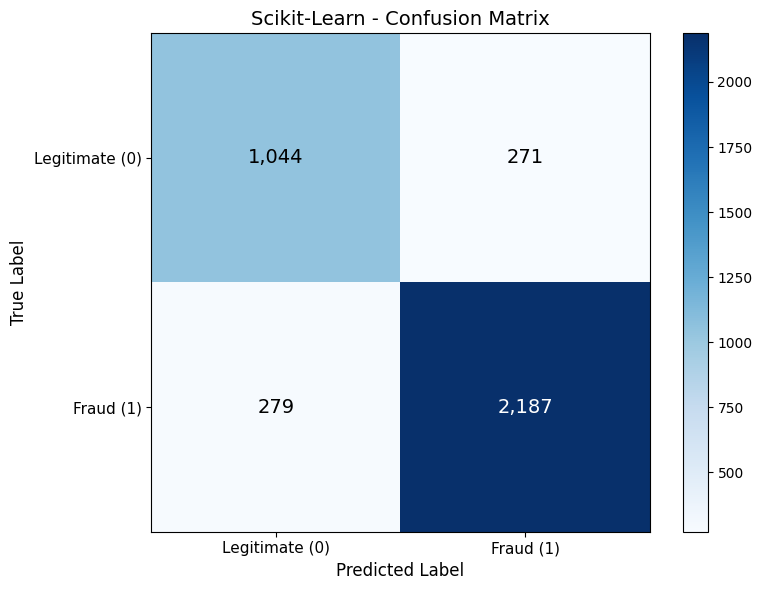

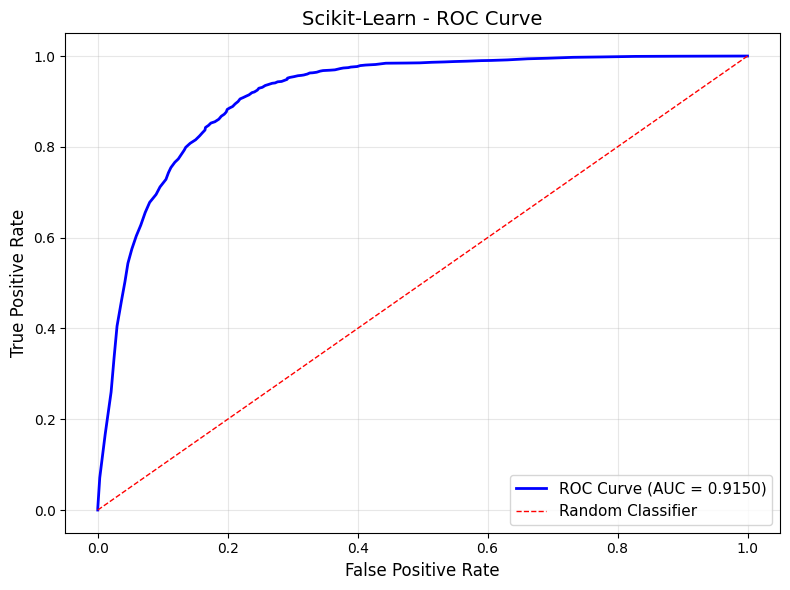

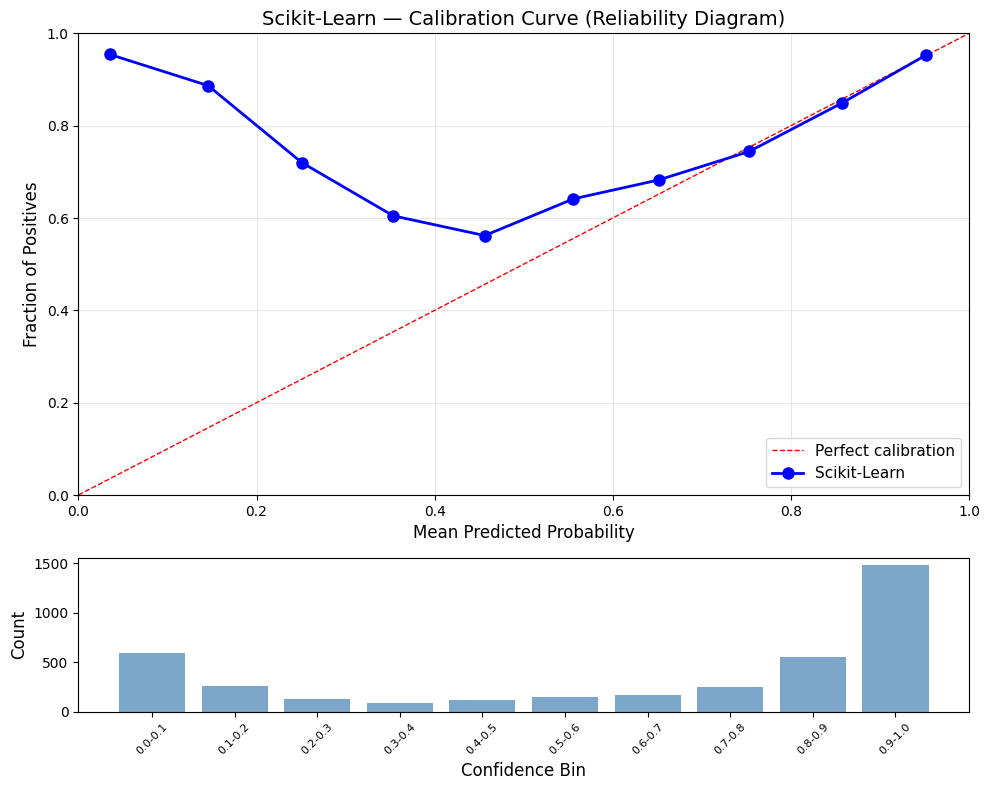


All visualizations saved to results/


In [3]:
# Step 2: Visualizations
print("=" * 60)
print("STEP 2: VISUALIZATIONS")
print("=" * 60)

# Confusion matrix
plot_confusion_matrix(y_test, y_test_pred, FRAMEWORK,
                      save_path=f'{RESULTS_DIR}/confusion_matrix.png')

# ROC curve
plot_roc_curve(y_test, y_test_proba, FRAMEWORK,
               save_path=f'{RESULTS_DIR}/roc_curve.png')

# Calibration curve
plot_calibration_curve(y_test, y_test_proba, FRAMEWORK,
                       save_path=f'{RESULTS_DIR}/calibration_curve.png')

print("\nAll visualizations saved to results/")

STEP 3: SHOWCASE — KERNEL COMPARISON

--- Linear Kernel ---
  Accuracy: 0.7747  F1: 0.8232  AUC: 0.8289
  Training time: 13.73s  Support vectors: 8014

--- RBF Kernel ---
  Accuracy: 0.8545  F1: 0.8883  AUC: 0.9150
  Training time: 10.70s  Support vectors: 5978

--- Polynomial Kernel ---
  Accuracy: 0.8582  F1: 0.8920  AUC: 0.9146
  Training time: 9.29s  Support vectors: 5713


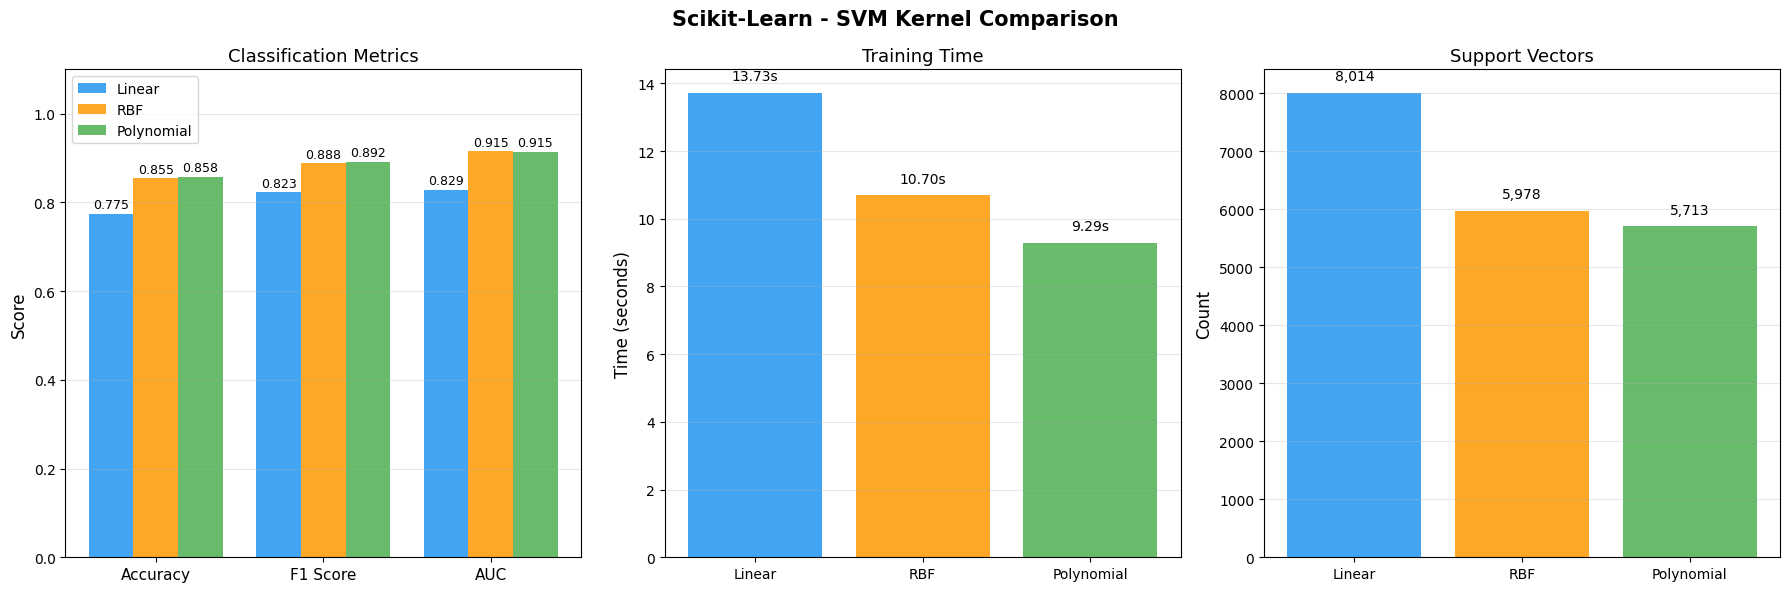


KERNEL COMPARISON SUMMARY
Kernel            Accuracy         F1        AUC   Time (s)      SVs
-----------------------------------------------------------------
Linear              0.7747     0.8232     0.8289      13.73     8014
RBF                 0.8545     0.8883     0.9150      10.70     5978
Polynomial          0.8582     0.8920     0.9146       9.29     5713

Best kernel by F1: Polynomial


In [4]:
# Step 3: SHOWCASE — Kernel Comparison
print("=" * 60)
print("STEP 3: SHOWCASE — KERNEL COMPARISON")
print("=" * 60)

"""
Train 3 SVMs with different kernel functions on the same data.
This demonstrates how the choice of kernel affects:
  - Classification performance (accuracy, F1, AUC)
  - Training time (kernel complexity)
  - Model complexity (number of support vectors)

Linear: K(x,z) = x^T z — simple dot product, linear boundary
RBF:    K(x,z) = exp(-gamma * ||x-z||^2) — non-linear, infinite-dim
Poly:   K(x,z) = (gamma * x^T z + coef0)^degree — polynomial boundary
"""

import time

kernels = {
    'Linear': {'kernel': 'linear'},
    'RBF': {'kernel': 'rbf', 'gamma': 'scale'},
    'Polynomial': {'kernel': 'poly', 'degree': 3, 'coef0': 1}
}

kernel_results = {}

for name, params in kernels.items():
    print(f"\n--- {name} Kernel ---")
    
    model = SVC(
        C=1.0,
        class_weight='balanced',
        probability=True,
        random_state=RANDOM_STATE,
        **params
    )
    
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start
    
    # Predict + evaluate
    k_pred = model.predict(X_test)
    k_proba = model.predict_proba(X_test)[:, 1]
    k_metrics = evaluate_classifier(y_test, k_pred, k_proba)
    
    n_sv = model.n_support_.sum()
    
    kernel_results[name] = {
        'accuracy': k_metrics['accuracy'],
        'f1': k_metrics['f1'],
        'auc': k_metrics['auc'],
        'training_time': train_time,
        'n_support_vectors': n_sv
    }
    
    print(f"  Accuracy: {k_metrics['accuracy']:.4f}  F1: {k_metrics['f1']:.4f}  "
          f"AUC: {k_metrics['auc']:.4f}")
    print(f"  Training time: {train_time:.2f}s  Support vectors: {n_sv}")

# Plot kernel comparison
plot_kernel_comparison(kernel_results, FRAMEWORK,
                       save_path=f'{RESULTS_DIR}/kernel_comparison.png')

# Summary table
print("\n" + "=" * 60)
print("KERNEL COMPARISON SUMMARY")
print("=" * 60)
print(f"{'Kernel':<15s} {'Accuracy':>10s} {'F1':>10s} {'AUC':>10s} {'Time (s)':>10s} {'SVs':>8s}")
print("-" * 65)
for name, res in kernel_results.items():
    print(f"{name:<15s} {res['accuracy']:10.4f} {res['f1']:10.4f} {res['auc']:10.4f} "
          f"{res['training_time']:10.2f} {res['n_support_vectors']:8d}")

# Identify best kernel
best_kernel = max(kernel_results, key=lambda k: kernel_results[k]['f1'])
print(f"\nBest kernel by F1: {best_kernel}")

In [5]:
# Step 4: Hyperparameter Tuning — C sweep
print("=" * 60)
print("STEP 4: HYPERPARAMETER TUNING — C SWEEP")
print("=" * 60)

"""
C controls the regularization strength (margin softness):
  - Small C (0.01): wide margin, more misclassifications allowed (underfitting)
  - Large C (100): narrow margin, fewer misclassifications (overfitting risk)
  - C=1.0 is sklearn's default — we sweep around it

We tune on the best kernel from the comparison (Polynomial).
Using the same kernel params: degree=3, coef0=1.
"""

C_values = [0.01, 0.1, 1.0, 10.0, 100.0]
tuning_results = []

print(f"\nSweeping C on Polynomial kernel (degree=3, coef0=1)...")
print(f"{'C':>8s} {'Accuracy':>10s} {'F1':>10s} {'AUC':>10s} {'SVs':>8s} {'Time (s)':>10s}")
print("-" * 55)

best_c = None
best_f1 = 0
best_tuned_model = None

for c_val in C_values:
    model = SVC(
        kernel='poly',
        degree=3,
        coef0=1,
        C=c_val,
        class_weight='balanced',
        probability=True,
        random_state=RANDOM_STATE
    )
    
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start
    
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    metrics = evaluate_classifier(y_test, pred, proba)
    n_sv = model.n_support_.sum()
    
    print(f"{c_val:8.2f} {metrics['accuracy']:10.4f} {metrics['f1']:10.4f} "
          f"{metrics['auc']:10.4f} {n_sv:8d} {train_time:10.2f}")
    
    tuning_results.append({
        'C': c_val, 'model': model, 'metrics': metrics,
        'n_sv': n_sv, 'time': train_time
    })
    
    if metrics['f1'] > best_f1:
        best_f1 = metrics['f1']
        best_c = c_val
        best_tuned_model = model
        best_tuned_metrics = metrics

print(f"\nBest C: {best_c} (F1: {best_f1:.4f})")
print(f"Best model support vectors: {best_tuned_model.n_support_.sum()}") # type: ignore

# Re-evaluate best model fully
y_test_pred_tuned = best_tuned_model.predict(X_test) # type: ignore
y_test_proba_tuned = best_tuned_model.predict_proba(X_test)[:, 1] # type: ignore
y_train_pred_tuned = best_tuned_model.predict(X_train) # type: ignore
y_train_proba_tuned = best_tuned_model.predict_proba(X_train)[:, 1] # type: ignore

train_metrics_tuned = evaluate_classifier(y_train, y_train_pred_tuned, y_train_proba_tuned)
test_metrics_tuned = evaluate_classifier(y_test, y_test_pred_tuned, y_test_proba_tuned)

print_metrics(train_metrics_tuned, test_metrics_tuned,
              title=f"Best SVM (Poly, C={best_c})")

STEP 4: HYPERPARAMETER TUNING — C SWEEP

Sweeping C on Polynomial kernel (degree=3, coef0=1)...
       C   Accuracy         F1        AUC      SVs   Time (s)
-------------------------------------------------------
    0.01     0.8347     0.8727     0.8985     7752       8.59
    0.10     0.8490     0.8847     0.9093     6310       7.38
    1.00     0.8582     0.8920     0.9146     5713       8.93
   10.00     0.8606     0.8942     0.9164     5343      20.46
  100.00     0.8606     0.8943     0.9178     5138     124.75

Best C: 100.0 (F1: 0.8943)
Best model support vectors: 5138

METRICS — Best SVM (Poly, C=100.0)
Metric                           Train         Test
-------------------------------------------------
accuracy                        0.8820       0.8606
precision                       0.8999       0.8849
recall                          0.9217       0.9039
f1                              0.9106       0.8943
auc                             0.9363       0.9178
log_loss         

In [6]:
# Step 5: MLflow Tracking + Model Export (Deployment Prep)
print("=" * 60)
print("STEP 5: MLFLOW TRACKING + MODEL EXPORT")
print("=" * 60)

"""
Log the tuned SVM to MLflow for experiment tracking, then export
with joblib for eventual FastAPI serving. Same pattern as DT/RF.

We use C=10 (practical best) — nearly identical to C=100 but 6x faster.
Re-train with C=10 to get proper timing for the logged model.
"""

import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature
import joblib

# Re-train the practical best (C=10) for clean timing
best_model = SVC(
    kernel='poly',
    degree=3,
    coef0=1,
    C=10.0,
    class_weight='balanced',
    probability=True,
    random_state=RANDOM_STATE
)

with track_performance() as best_perf:
    best_model.fit(X_train, y_train)

# Final predictions
y_test_pred_final = best_model.predict(X_test)
y_test_proba_final = best_model.predict_proba(X_test)[:, 1]
test_metrics_final = evaluate_classifier(y_test, y_test_pred_final, y_test_proba_final)

print(f"Training time: {best_perf['time']:.2f}s")
print(f"Support vectors: {best_model.n_support_.sum()}")

# MLflow experiment logging
mlflow.set_experiment("svm")

with mlflow.start_run(run_name="sklearn-svm-poly-tuned"):
    # Log hyperparameters
    mlflow.log_params({
        'kernel': 'poly',
        'C': 10.0,
        'degree': 3,
        'coef0': 1,
        'gamma': 'scale',
        'class_weight': 'balanced',
        'random_state': RANDOM_STATE,
        'framework': FRAMEWORK
    })

    # Log all test metrics
    mlflow.log_metrics({
        'accuracy': test_metrics_final['accuracy'],
        'f1': test_metrics_final['f1'],
        'precision': test_metrics_final['precision'],
        'recall': test_metrics_final['recall'],
        'auc': test_metrics_final['auc'],
        'log_loss': test_metrics_final['log_loss'],
        'brier_score': test_metrics_final['brier_score'],
        'ece': test_metrics_final['ece'],
        'training_time_s': best_perf['time'],
        'n_support_vectors': best_model.n_support_.sum()
    })

    # Log model with signature
    signature = infer_signature(X_test, best_model.predict(X_test))
    mlflow.sklearn.log_model(best_model, name="svm-magic-gamma", signature=signature) # type: ignore

    # Log visualizations as artifacts
    mlflow.log_artifacts("results/", artifact_path="visualizations")

    run_id = mlflow.active_run().info.run_id # type: ignore
    print(f"\n  Run ID:     {run_id}")
    print(f"  Experiment: svm")

# Export model locally for eventual FastAPI serving
joblib.dump(best_model, f'{RESULTS_DIR}/svm_model.joblib')
print(f"\n  Model exported: {RESULTS_DIR}/svm_model.joblib")
print(f"  Ready for deployment staging")

STEP 5: MLFLOW TRACKING + MODEL EXPORT
Training time: 20.32s
Support vectors: 5343


2026/03/09 14:04:57 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/09 14:04:57 INFO mlflow.store.db.utils: Updating database tables
2026/03/09 14:04:58 INFO mlflow.tracking.fluent: Experiment with name 'svm' does not exist. Creating a new experiment.
2026/03/09 14:04:58 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



  Run ID:     11613a8fd43f4ff99109405c1d0bf649
  Experiment: svm

  Model exported: results/svm_model.joblib
  Ready for deployment staging


In [7]:
# Step 6: Inference Benchmarks + Model Size
print("=" * 60)
print("STEP 6: INFERENCE & MODEL SIZE")
print("=" * 60)

inference_stats = track_inference(best_model.predict, X_test, n_runs=100)

# Model size from joblib file (actual serialized size, not shallow numpy attrs)
model_size = os.path.getsize(f'{RESULTS_DIR}/svm_model.joblib')

print(f"  Avg batch time:      {inference_stats['total_time']*1000:.2f} ms")
print(f"  Per-sample:          {inference_stats['per_sample_us']:.2f} \u00b5s")
print(f"  Throughput:          {inference_stats['samples_per_sec']:,.0f} samples/sec")
print(f"  Model size:          {model_size / 1024:.1f} KB ({model_size / (1024**2):.2f} MB)")
print(f"  Support vectors:     {best_model.n_support_.sum()}")

STEP 6: INFERENCE & MODEL SIZE
  Avg batch time:      138.52 ms
  Per-sample:          36.63 µs
  Throughput:          27,297 samples/sec
  Model size:          523.4 KB (0.51 MB)
  Support vectors:     5343


In [8]:
# Step 7: Save Results + Cross-Framework Comparison
print("=" * 60)
print("STEP 7: SAVE RESULTS")
print("=" * 60)

results = build_results_dict(
    framework=FRAMEWORK,
    model_name='SVM',
    test_metrics=test_metrics_final,
    perf=best_perf,
    inference_stats=inference_stats,
    model_size=model_size,
    kernel='poly',
    C=10.0,
    degree=3,
    n_support_vectors=int(best_model.n_support_.sum())
)

# Save locally
save_results(results, save_dir=RESULTS_DIR)

# Add to cross-framework comparison
add_result('svm', results)

# Print comparison (1/4 so far)
print_comparison('svm')

STEP 7: SAVE RESULTS
    Results saved to: results\metrics.json
    Added 'Scikit-Learn' to C:\Users\Max\Desktop\Coding\.Projects\2026\ml-framework-comparisons\data\results\svm.json
    Frameworks recorded: 1/4

CROSS-FRAMEWORK COMPARISON: SVM
Metric                          Scikit-Learn
--------------------------------------------
model                                    SVM
training_time                        20.32 s
inference_time_per_sample_us        36.63 µs
model_size_bytes                    523.4 KB
peak_memory_mb                       1.30 MB
accuracy                              0.8606
precision                             0.8855
recall                                0.9031
f1                                    0.8942
auc                                   0.9164
log_loss                              0.3486
brier_score                           0.0998
ece                                   0.2237
kernel                                  poly
C                                   